# FORTIFY Trojan-output mining and leakage-path plots

This notebook uses `fortify_trojan_miner.py` for graph construction, cached analysis, and Trojan-output ranking.
All plotting is kept near the end of the notebook. The `.py` file prints candidate Trojan outputs and does not generate plots.


In [1]:

# -----------------------------
# User parameters
# -----------------------------
from pathlib import Path

PROJECT_ROOT = Path("fortify")
RUN_NAME = "aes"
OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs" / "leakage_topology"

AES_SIZES = [100, 200, 700, 800, 1100, 1200, 1600, 1700]
DESIGN_NAME_TEMPLATE = "aes{size}"
RESULT_SUBDIR_TEMPLATE = "{design}_recon"
VERILOG_FILE_TEMPLATE = "AES{size}.v"

PARENTS_FILENAME = "parents.txt"
LEAKAGE_FILENAME = "all_signal_leakage.csv"

# Rerun from parents/leakage CSV only when you want to ignore saved caches.
RERUN_FROM_SCRATCH = False

# Group signal@t instances and report only the maximum-scoring representative.
GROUP_TIME_INSTANCES = True

# Use only configured primary-output buses as candidate Trojan outputs.
PRIMARY_OUTPUTS_ONLY = True
PRIMARY_OUTPUT_BASES = ["top.Capacitance", "top.out"]

# Keep this broad for recall-first Trojan-output mining.
OUTPUT_NODE_MODE = "primary_bases"
OUTPUT_PREFIXES = ["top.Capacitance", "top.out"]

# Exclude module input pins such as .in, .in[3], and .in[3:3].
EXCLUDE_INPUT_LIKE_CANDIDATES = True

# Score all candidate outputs by default; use an integer only for a speed/debug run.
TROJAN_MAX_OUTPUT_CANDIDATES_TO_SCORE = None

# Penalize candidates whose fanin cones have too few leakage-valued nodes.
TROJAN_MIN_FANIN_LEAKAGE_NODES = 5

# Define the near-output region used by near-vs-far path leakage features.
TROJAN_NEAR_TARGET_DISTANCE = 3

# Number of candidates printed in notebook tables.
REPORT_TOP_N = 100

# Number of top candidates whose fanin lines are plotted.
MAX_FANIN_PLOT_TARGETS = 8

# Maximum number of fanin edges drawn per design plot.
MAX_FANIN_EDGES_DRAWN = 60000

# Plot log10(leakage + eps) to make tiny leakage values visible.
PLOT_LOG_LEAKAGE = True
LEAKAGE_EPS = 1e-30

# Display compact summary figures in the notebook while saving individual graphs.
DISPLAY_PLOTS_IN_NOTEBOOK = True
DISPLAY_PER_DESIGN_SUMMARIES = True

# Save one standalone PNG for each graph, even when the notebook displays a clubbed summary.
SAVE_SINGLE_GRAPHS = True

# Categorical colors make different designs easier to distinguish.
DESIGN_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#17becf",
    "#000000", "#999999",
]


In [2]:

# -----------------------------
# Imports and shared miner setup
# -----------------------------
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from IPython.display import display

# The notebook expects fortify_trojan_miner.py to be in the current directory or beside the notebook.
sys.path.insert(0, str(Path.cwd()))

import fortify_trojan_miner as miner
importlib.reload(miner)

# Keep notebook parameters and the CLI/core module synchronized.
miner.PROJECT_ROOT = PROJECT_ROOT
miner.RESULTS_ROOT = PROJECT_ROOT / "results"
miner.RUN_NAME = RUN_NAME
miner.OUTPUT_ROOT = OUTPUT_ROOT
miner.PARENTS_FILENAME = PARENTS_FILENAME
miner.LEAKAGE_FILENAME = LEAKAGE_FILENAME
miner.AES_SIZES = AES_SIZES
miner.DESIGN_NAME_TEMPLATE = DESIGN_NAME_TEMPLATE
miner.RESULT_SUBDIR_TEMPLATE = RESULT_SUBDIR_TEMPLATE
miner.VERILOG_FILE_TEMPLATE = VERILOG_FILE_TEMPLATE
miner.GROUP_TIME_INSTANCES = GROUP_TIME_INSTANCES
miner.PRIMARY_OUTPUTS_ONLY = PRIMARY_OUTPUTS_ONLY
miner.PRIMARY_OUTPUT_BASES = PRIMARY_OUTPUT_BASES
miner.OUTPUT_NODE_MODE = OUTPUT_NODE_MODE
miner.OUTPUT_PREFIXES = OUTPUT_PREFIXES
miner.EXCLUDE_INPUT_LIKE_CANDIDATES = EXCLUDE_INPUT_LIKE_CANDIDATES
miner.TROJAN_MAX_OUTPUT_CANDIDATES_TO_SCORE = TROJAN_MAX_OUTPUT_CANDIDATES_TO_SCORE
miner.TROJAN_MIN_FANIN_LEAKAGE_NODES = TROJAN_MIN_FANIN_LEAKAGE_NODES
miner.TROJAN_NEAR_TARGET_DISTANCE = TROJAN_NEAR_TARGET_DISTANCE
miner.LEAKAGE_EPS = LEAKAGE_EPS

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 120)


In [3]:

# -----------------------------
# Run cached analysis and print candidate outputs
# -----------------------------
design_specs = miner.make_design_specs(
    sizes=AES_SIZES,
    project_root=PROJECT_ROOT,
    run_name=RUN_NAME,
    design_name_template=DESIGN_NAME_TEMPLATE,
    result_subdir_template=RESULT_SUBDIR_TEMPLATE,
    verilog_file_template=VERILOG_FILE_TEMPLATE,
)

all_bundles, errors = miner.analyze_all_designs(
    design_specs,
    force=RERUN_FROM_SCRATCH,
    group_time=GROUP_TIME_INSTANCES,
)

if errors:
    print("Errors:")
    for design, msg in errors:
        print(f"  {design}: {msg}")

combined_candidates_df = miner.combined_candidates(all_bundles, group_time=GROUP_TIME_INSTANCES)
combined_candidates_path = miner.save_combined_candidates(combined_candidates_df, OUTPUT_ROOT)

print(f"Analyzed designs: {len(all_bundles)}")
print(f"Saved combined candidates to: {combined_candidates_path}")

display(
    combined_candidates_df
    .head(REPORT_TOP_N)
    .loc[:, [c for c in [
        "combined_rank", "design", "candidate_output", "representative_output",
        "trojan_candidate_score", "leakage", "best_ref",
        "output_same_level_percentile", "output_robust_z",
        "fanin_auc_vs_rest", "fanin_median_same_level_percentile",
        "fanin_same_level_top5_frac", "reason",
    ] if c in combined_candidates_df.columns]]
)


Analyzed designs: 8
Saved combined candidates to: fortify/analysis_outputs/leakage_topology/combined_trojan_output_candidates.csv


,combined_rank,design,candidate_output,representative_output,trojan_candidate_score,leakage,best_ref,output_same_level_percentile,output_robust_z,fanin_auc_vs_rest,fanin_median_same_level_percentile,fanin_same_level_top5_frac,reason
0,1,aes100,top.Capacitance[47:47],top.Capacitance[47:47]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
1,2,aes100,top.Capacitance[46:46],top.Capacitance[46:46]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
2,3,aes100,top.Capacitance[45:45],top.Capacitance[45:45]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
3,4,aes100,top.Capacitance[44:44],top.Capacitance[44:44]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
4,5,aes100,top.Capacitance[43:43],top.Capacitance[43:43]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
5,6,aes100,top.Capacitance[42:42],top.Capacitance[42:42]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
6,7,aes100,top.Capacitance[41:41],top.Capacitance[41:41]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
7,8,aes100,top.Capacitance[40:40],top.Capacitance[40:40]@20,62.117286,0.484690,top.key[5:5],0.990691,1.978753e+09,0.432802,0.500896,0.153846,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
8,9,aes100,top.Capacitance[7:7],top.Capacitance[7:7]@20,62.034635,0.443111,top.key[0:0],0.990278,1.809007e+09,0.482110,0.500896,0.200000,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift
9,10,aes100,top.Capacitance[6:6],top.Capacitance[6:6]@20,62.034635,0.443111,top.key[0:0],0.990278,1.809007e+09,0.482110,0.500896,0.200000,output same-level outlier; output robust-z high; many fanin level-outliers; near-output lift


In [4]:

# -----------------------------
# Compact numerical summary
# -----------------------------
summary_rows = []
for bundle in all_bundles:
    stats = dict(bundle["stats"])
    stats["loaded_from_cache"] = bundle.get("loaded_from_cache", False)
    summary_rows.append(stats)

analysis_summary_df = pd.DataFrame(summary_rows)
analysis_summary_path = OUTPUT_ROOT / "analysis_summary.csv"
analysis_summary_df.to_csv(analysis_summary_path, index=False)

print(f"Saved analysis summary to: {analysis_summary_path}")
display(analysis_summary_df)


Saved analysis summary to: fortify/analysis_outputs/leakage_topology/analysis_summary.csv


,design,nodes,edges,is_dag,strongly_connected_components,topological_levels,leakage_nodes,output_candidates_scored,output_candidates_reported,max_candidate_score,loaded_from_cache
0,aes100,80626,98310,False,80586,122,76089,192,192,62.117286,False
1,aes200,78942,93958,True,0,130,78814,192,192,49.664506,False
2,aes700,80760,99303,False,80720,122,76223,192,192,57.579760,False
3,aes800,83253,101792,False,83213,130,78716,192,192,58.214578,False
4,aes1100,83253,102176,False,83213,130,78716,192,192,58.219838,False
5,aes1200,120635,181987,False,120595,471,76371,192,192,53.726664,False
6,aes1600,83259,536567,False,83258,130,78648,128,128,49.247933,False
7,aes1700,116718,2246781,True,0,135,78769,128,128,49.260943,False


In [5]:

# -----------------------------
# Plot helpers
# -----------------------------

def design_color(design_index):
    # Use high-contrast categorical colors across designs.
    return DESIGN_COLORS[design_index % len(DESIGN_COLORS)]


def plot_y_values(df):
    # Use log leakage by default so very small values remain visible.
    if PLOT_LOG_LEAKAGE:
        return np.log10(pd.to_numeric(df["leakage"], errors="coerce").fillna(0.0) + LEAKAGE_EPS)
    return pd.to_numeric(df["leakage"], errors="coerce")


def top_candidates(bundle, n=MAX_FANIN_PLOT_TARGETS):
    # Select top grouped candidate outputs for path plotting.
    df = bundle["candidates_df"].copy()
    if df.empty:
        return []
    return df.sort_values("trojan_candidate_score", ascending=False)["representative_output" if "representative_output" in df.columns else "candidate_output"].head(n).astype(str).tolist()


def node_coordinates(node_df):
    # Build coordinates x=topological level and y=leakage/log-leakage.
    df = node_df.copy()
    df["x"] = pd.to_numeric(df["topological_level"], errors="coerce")
    df["y"] = plot_y_values(df)
    return dict(zip(df["node"], zip(df["x"], df["y"])))


def fanin_edges_for_targets(G, targets):
    # Collect the union of fanin edges for the selected candidate outputs.
    cone_nodes = set()
    cone_edges = set()
    for target in targets:
        nodes, edges, _ = miner.fanin_cone_for_target(G, target)
        cone_nodes |= nodes
        cone_edges |= edges
    return cone_nodes, cone_edges


def make_segments(coord, edges, max_edges):
    # Convert graph edges to Matplotlib line segments.
    segments = []
    missing = 0
    for parent, child in edges:
        if parent not in coord or child not in coord:
            missing += 1
            continue
        x0, y0 = coord[parent]
        x1, y1 = coord[child]
        if pd.isna(x0) or pd.isna(x1) or pd.isna(y0) or pd.isna(y1):
            continue
        segments.append([(x0, y0), (x1, y1)])
        if len(segments) >= max_edges:
            break
    return segments, missing


def save_fig(fig, path):
    # Save every standalone figure for later use.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path


def draw_candidate_score_bar(ax, bundle, top_n=30):
    # Plot top candidate output scores for one design.
    df = bundle["candidates_df"].copy().head(top_n)
    if df.empty:
        ax.set_title(f"{bundle['design']}: no candidates")
        return

    labels = df["candidate_output"].astype(str).tolist()[::-1]
    values = df["trojan_candidate_score"].tolist()[::-1]

    ax.barh(range(len(labels)), values)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Trojan candidate score")
    ax.set_title(f"{bundle['design']}: top candidate outputs")
    ax.grid(axis="x", alpha=0.25)


def draw_component_heatmap(ax, bundle, top_n=20):
    # Show which statistical features drive the candidate ranking.
    df = bundle["candidates_df"].copy().head(top_n)
    if df.empty:
        ax.set_title(f"{bundle['design']}: no components")
        return

    cols = [
        "output_leakage_percentile",
        "output_same_level_percentile",
        "fanin_auc_vs_rest",
        "fanin_median_same_level_percentile",
        "fanin_same_level_top5_frac",
        "path_size_confidence",
    ]
    cols = [c for c in cols if c in df.columns]
    mat = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy()

    im = ax.imshow(mat, aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["candidate_output"].astype(str), fontsize=7)
    ax.set_title(f"{bundle['design']}: score evidence components")
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)


def draw_leakage_level_overlay(ax, bundle, design_index=0, top_n=MAX_FANIN_PLOT_TARGETS):
    # Plot all leakage nodes by topological level and overlay candidate fanin paths.
    df = bundle["node_df"].copy()
    leak_df = df[df["has_leakage"] == True].copy()
    color = design_color(design_index)

    ax.scatter(
        leak_df["topological_level"],
        plot_y_values(leak_df),
        s=5,
        alpha=0.15,
        color="gray",
        linewidths=0,
        label="all leakage nodes",
    )

    targets = top_candidates(bundle, top_n)
    cone_nodes, cone_edges = fanin_edges_for_targets(bundle["graph"], targets)
    cone_df = leak_df[leak_df["node"].isin(cone_nodes)].copy()

    coord = node_coordinates(df)
    segments, missing = make_segments(coord, cone_edges, MAX_FANIN_EDGES_DRAWN)

    if segments:
        lc = LineCollection(segments, colors=color, linewidths=1.15, alpha=0.55, zorder=2)
        ax.add_collection(lc)

    if not cone_df.empty:
        ax.scatter(
            cone_df["topological_level"],
            plot_y_values(cone_df),
            s=10,
            alpha=0.75,
            color=color,
            linewidths=0,
            label="fanin nodes",
        )

    target_df = leak_df[leak_df["node"].isin(targets)].copy()
    if not target_df.empty:
        ax.scatter(
            target_df["topological_level"],
            plot_y_values(target_df),
            s=80,
            facecolors="none",
            edgecolors="black",
            linewidths=1.2,
            label="candidate outputs",
        )

    ylabel = "log10(Leakage_PBV + eps)" if PLOT_LOG_LEAKAGE else "Leakage_PBV"
    ax.set_xlabel("Topological level")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{bundle['design']}: fanin paths of top candidates")
    ax.grid(alpha=0.25)


def draw_ecdf_cone_vs_rest(ax, bundle, top_n=MAX_FANIN_PLOT_TARGETS):
    # Compare leakage distribution of candidate fanin cones against the rest of the graph.
    df = bundle["node_df"].copy()
    leak_df = df[df["has_leakage"] == True].copy()

    targets = top_candidates(bundle, top_n)
    cone_nodes, _ = fanin_edges_for_targets(bundle["graph"], targets)

    cone = pd.to_numeric(leak_df[leak_df["node"].isin(cone_nodes)]["leakage"], errors="coerce").dropna()
    rest = pd.to_numeric(leak_df[~leak_df["node"].isin(cone_nodes)]["leakage"], errors="coerce").dropna()

    def draw(values, label):
        vals = np.sort(values.to_numpy())
        if len(vals) == 0:
            return
        ys = np.arange(1, len(vals) + 1) / len(vals)
        xs = np.log10(vals + LEAKAGE_EPS) if PLOT_LOG_LEAKAGE else vals
        ax.plot(xs, ys, label=label)

    draw(cone, "top-candidate fanin")
    draw(rest, "rest of graph")

    ax.set_xlabel("log10(Leakage_PBV + eps)" if PLOT_LOG_LEAKAGE else "Leakage_PBV")
    ax.set_ylabel("ECDF")
    ax.set_title(f"{bundle['design']}: fanin vs rest leakage distribution")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)


def save_individual_graphs(bundle, design_index=0):
    # Save each graph as a standalone PNG even though summaries are displayed together.
    if not SAVE_SINGLE_GRAPHS:
        return []

    out_dir = Path(bundle["out_dir"])
    saved = []

    fig, ax = plt.subplots(figsize=(12, 7))
    draw_candidate_score_bar(ax, bundle, top_n=min(REPORT_TOP_N, 40))
    saved.append(save_fig(fig, out_dir / f"{bundle['design']}_candidate_score_bar.png"))
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(13, 7))
    draw_component_heatmap(ax, bundle, top_n=min(REPORT_TOP_N, 25))
    saved.append(save_fig(fig, out_dir / f"{bundle['design']}_candidate_component_heatmap.png"))
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(14, 7))
    draw_leakage_level_overlay(ax, bundle, design_index=design_index)
    saved.append(save_fig(fig, out_dir / f"{bundle['design']}_fanin_overlay_by_level.png"))
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 6))
    draw_ecdf_cone_vs_rest(ax, bundle)
    saved.append(save_fig(fig, out_dir / f"{bundle['design']}_ecdf_fanin_vs_rest.png"))
    plt.close(fig)

    return saved


def display_design_summary(bundle, design_index=0):
    # Display a clean 2x2 summary for one design.
    fig, axes = plt.subplots(2, 2, figsize=(22, 14))

    draw_candidate_score_bar(axes[0, 0], bundle, top_n=min(REPORT_TOP_N, 25))
    draw_component_heatmap(axes[0, 1], bundle, top_n=min(REPORT_TOP_N, 15))
    draw_leakage_level_overlay(axes[1, 0], bundle, design_index=design_index)
    draw_ecdf_cone_vs_rest(axes[1, 1], bundle)

    fig.suptitle(f"{bundle['design']}: Trojan-output mining summary", fontsize=16)
    fig.tight_layout()

    path = Path(bundle["out_dir"]) / f"{bundle['design']}_summary_grid.png"
    save_fig(fig, path)

    if DISPLAY_PLOTS_IN_NOTEBOOK:
        display(fig)

    plt.close(fig)
    return path


def display_combined_overlay(bundles):
    # Overlay top-candidate fanin paths from all designs with distinct colors.
    fig, ax = plt.subplots(figsize=(18, 8))

    legend_handles = []

    for i, bundle in enumerate(bundles):
        color = design_color(i)
        df = bundle["node_df"].copy()
        leak_df = df[df["has_leakage"] == True].copy()

        ax.scatter(
            leak_df["topological_level"],
            plot_y_values(leak_df),
            s=3,
            alpha=0.04,
            color="gray",
            linewidths=0,
        )

        targets = top_candidates(bundle, MAX_FANIN_PLOT_TARGETS)
        cone_nodes, cone_edges = fanin_edges_for_targets(bundle["graph"], targets)
        coord = node_coordinates(df)
        segments, _ = make_segments(coord, cone_edges, MAX_FANIN_EDGES_DRAWN)

        if segments:
            lc = LineCollection(segments, colors=color, linewidths=1.3, alpha=0.55, zorder=2)
            ax.add_collection(lc)

        legend_handles.append(Line2D([0], [0], color=color, lw=2.0, label=bundle["design"]))

    ax.set_xlabel("Topological level")
    ax.set_ylabel("log10(Leakage_PBV + eps)" if PLOT_LOG_LEAKAGE else "Leakage_PBV")
    ax.set_title("Top-candidate fanin paths across all designs")
    ax.grid(alpha=0.25)
    ax.legend(handles=legend_handles, title="Design", frameon=False, fontsize=8)

    fig.tight_layout()

    path = OUTPUT_ROOT / "combined_top_candidate_fanin_overlay.png"
    save_fig(fig, path)

    if DISPLAY_PLOTS_IN_NOTEBOOK:
        display(fig)

    plt.close(fig)
    return path


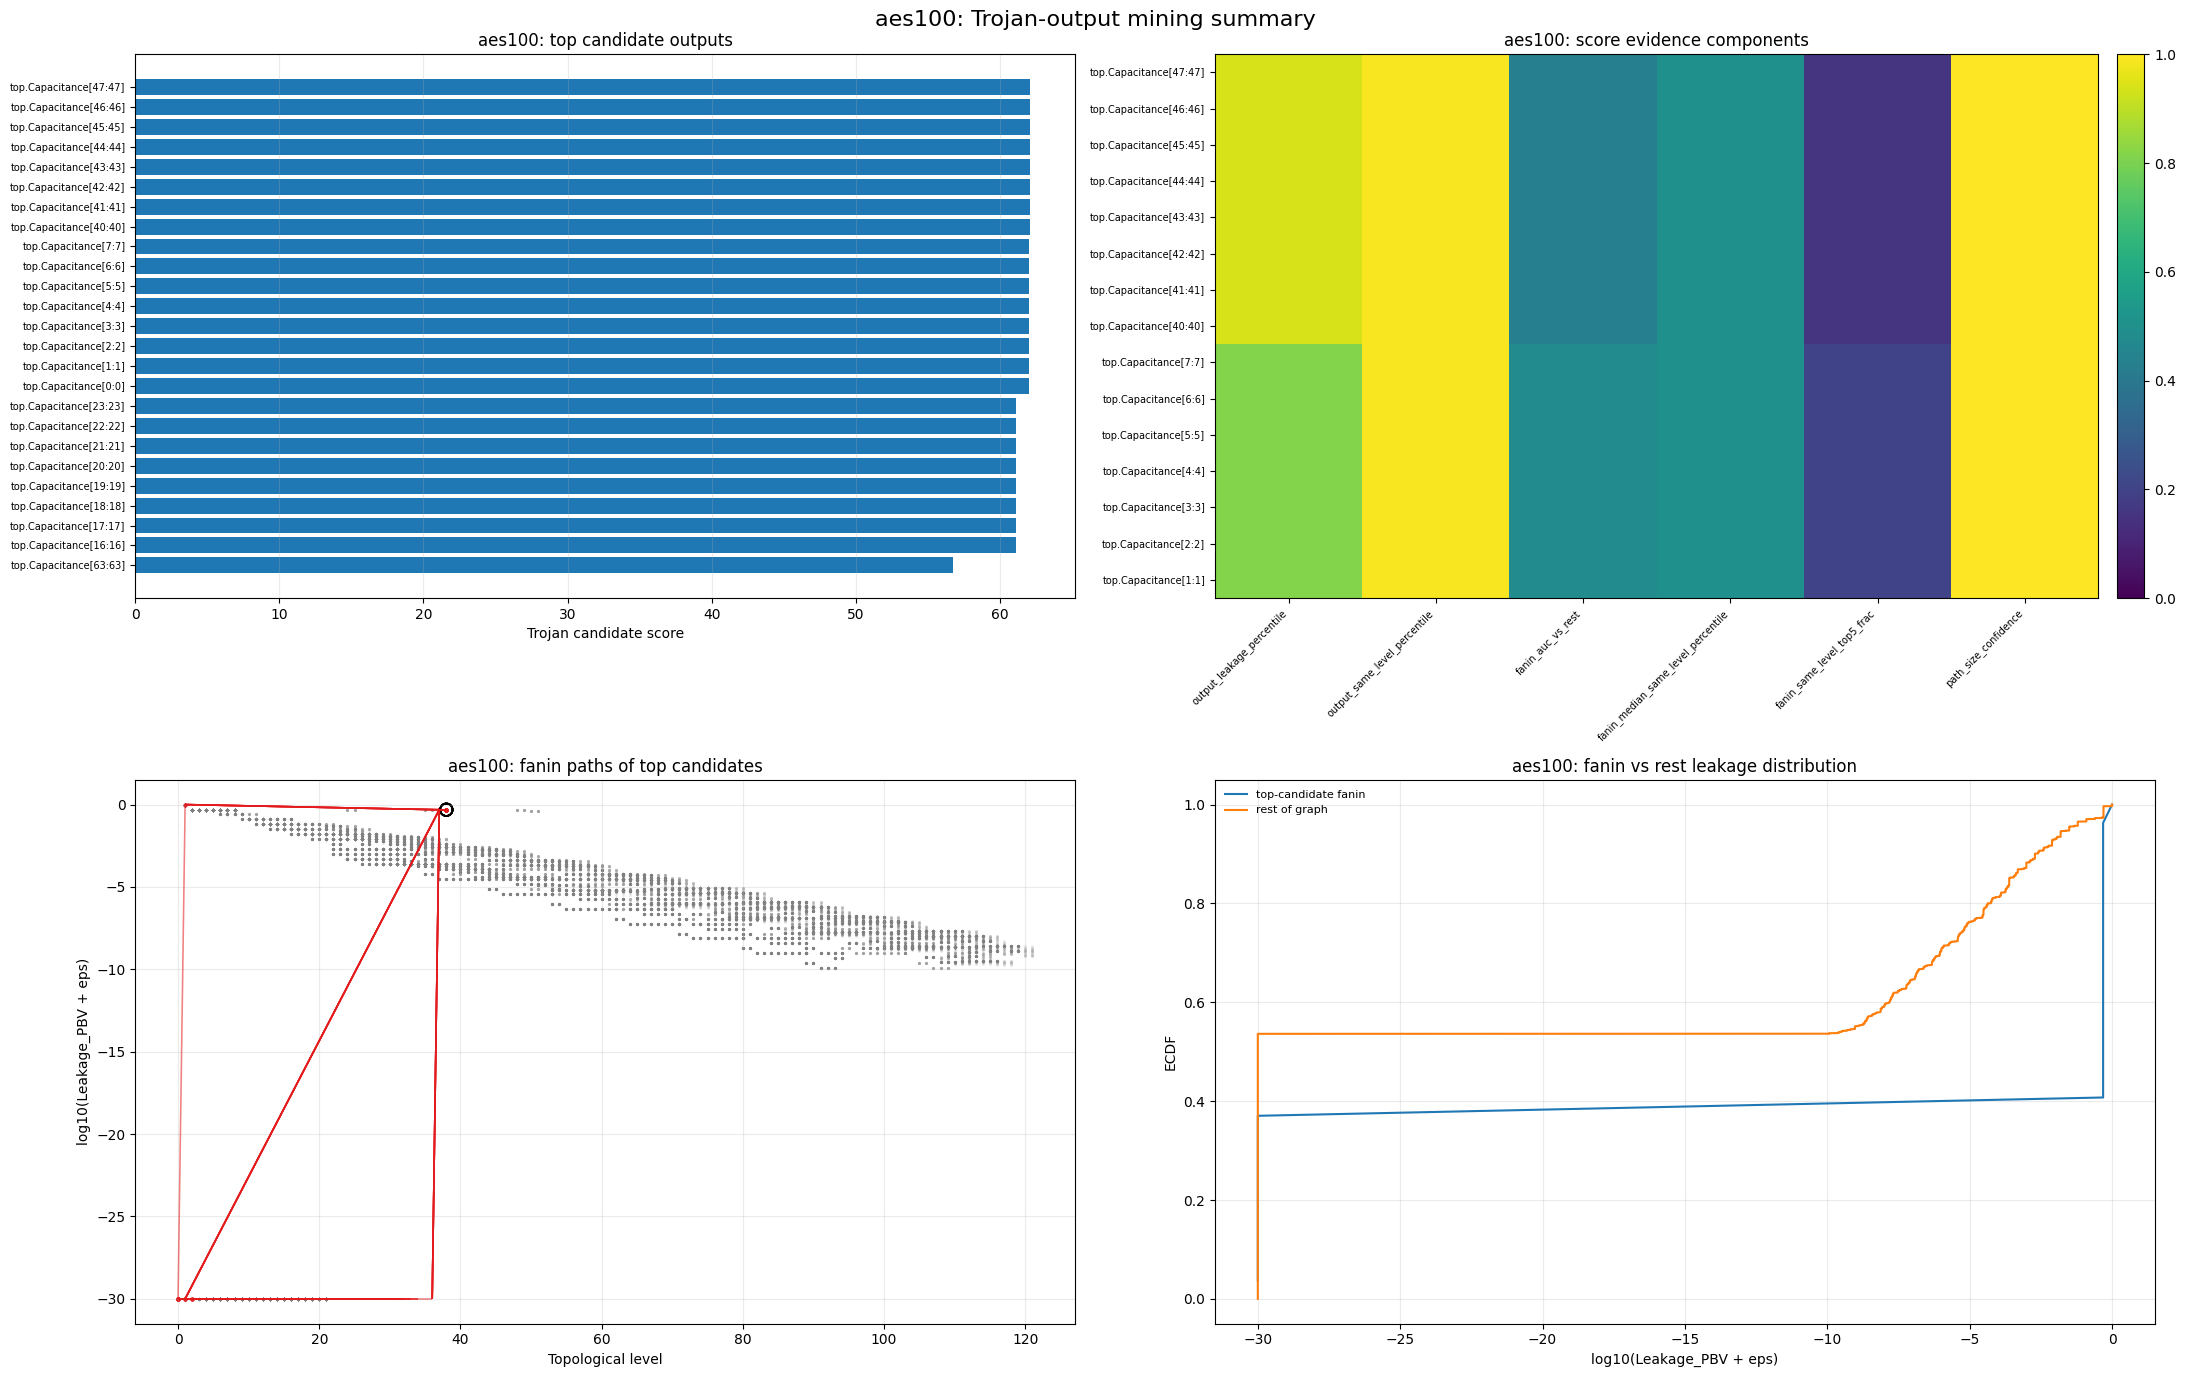

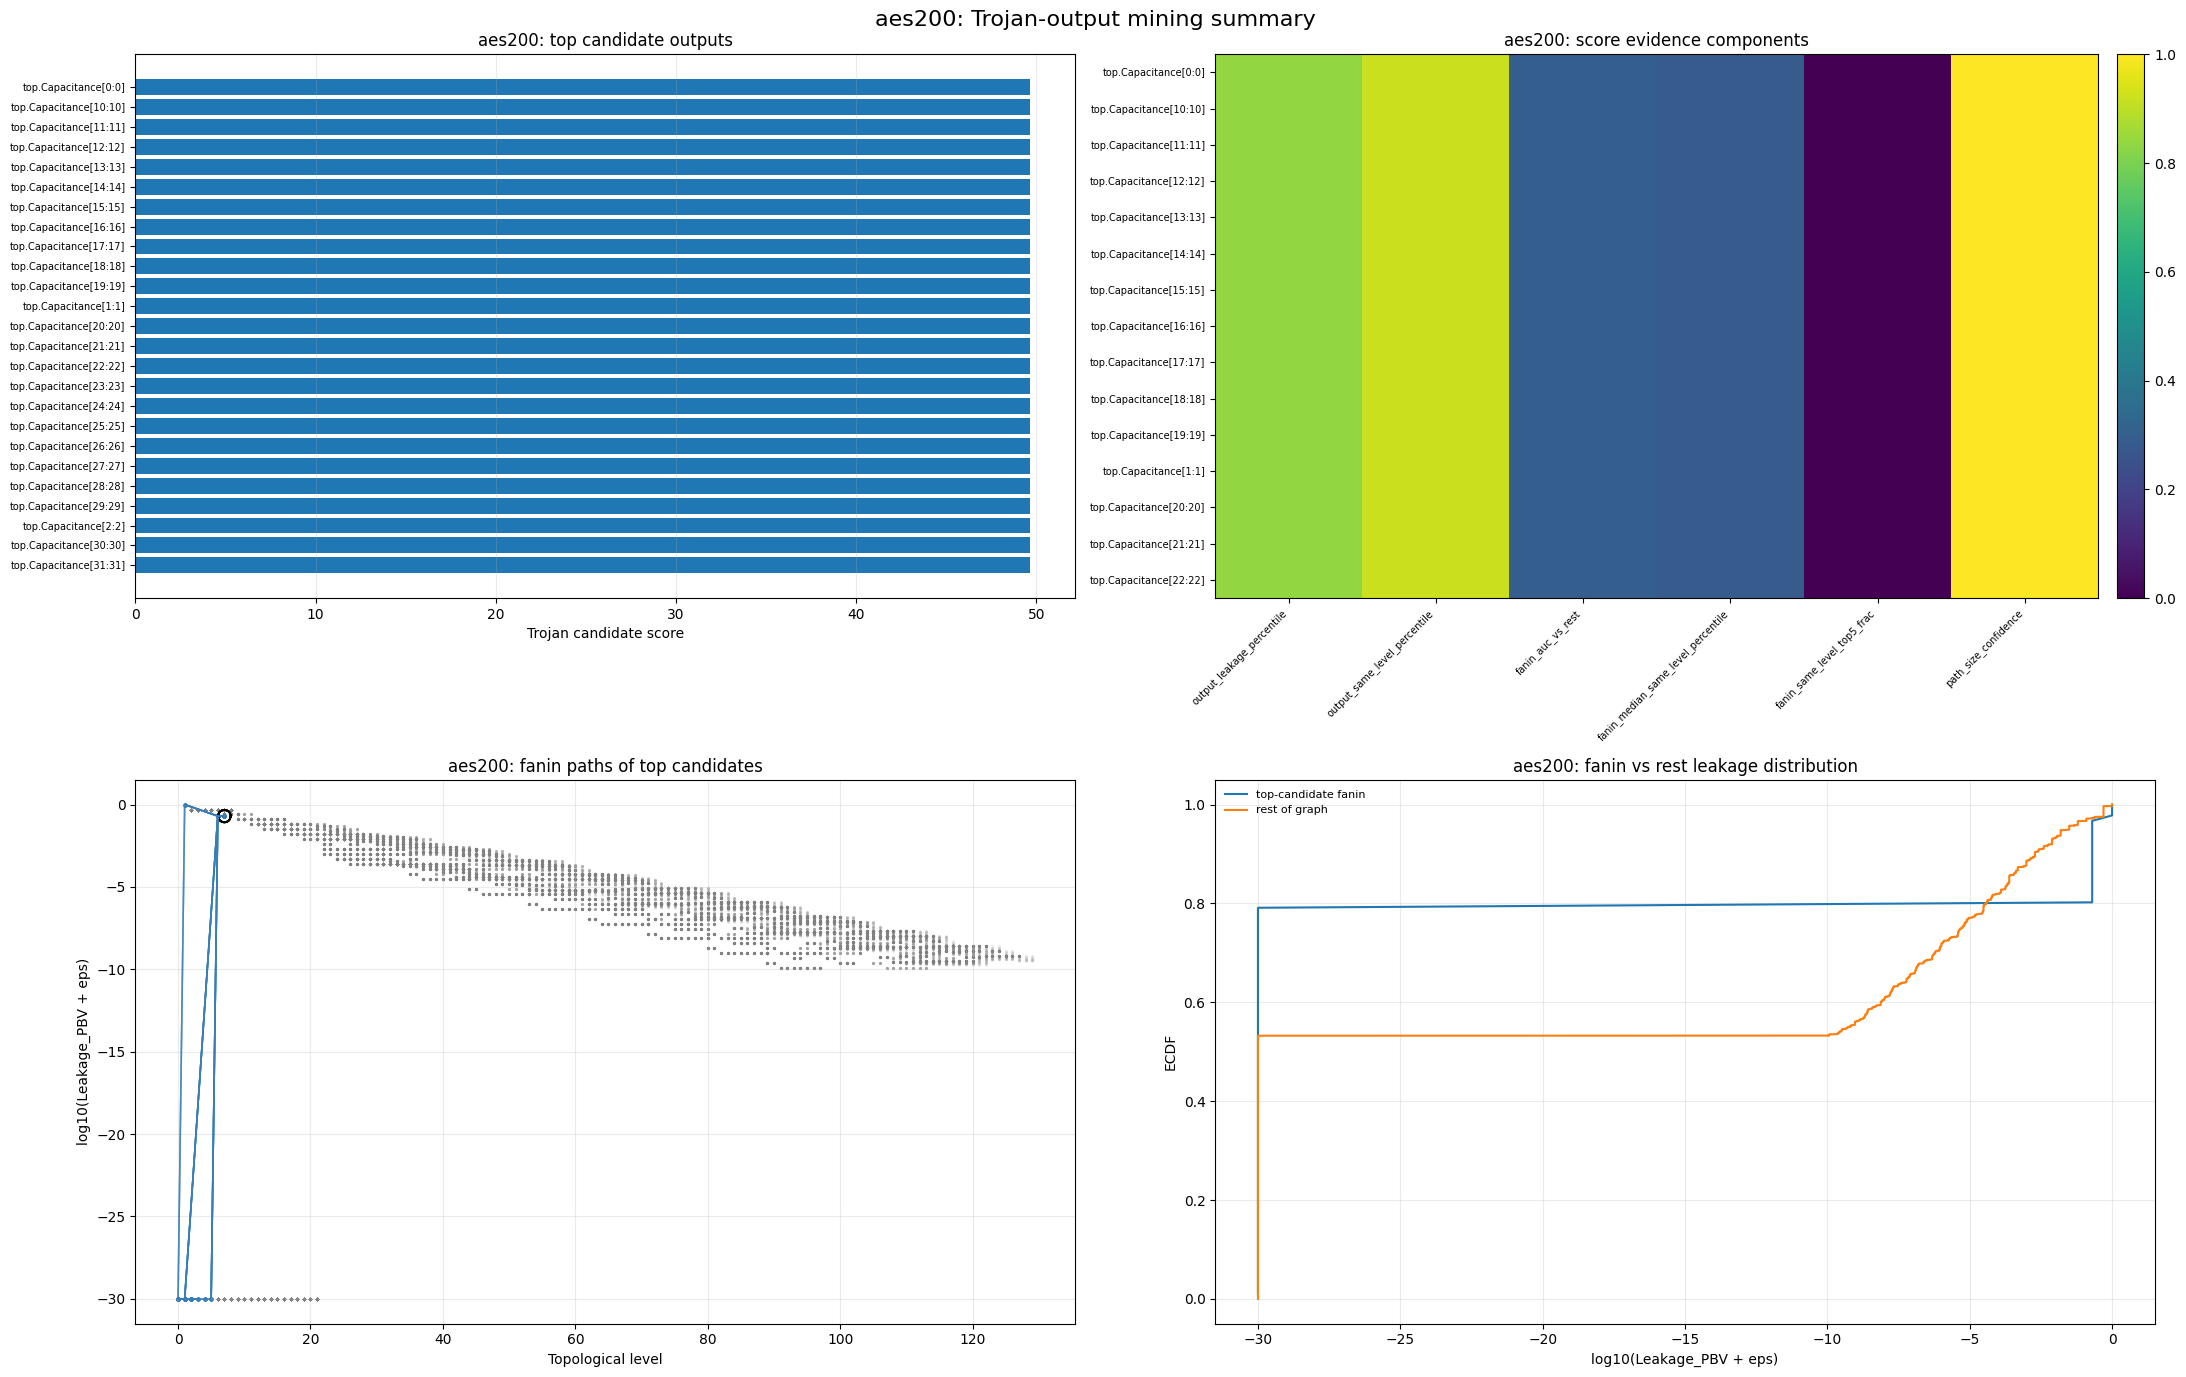

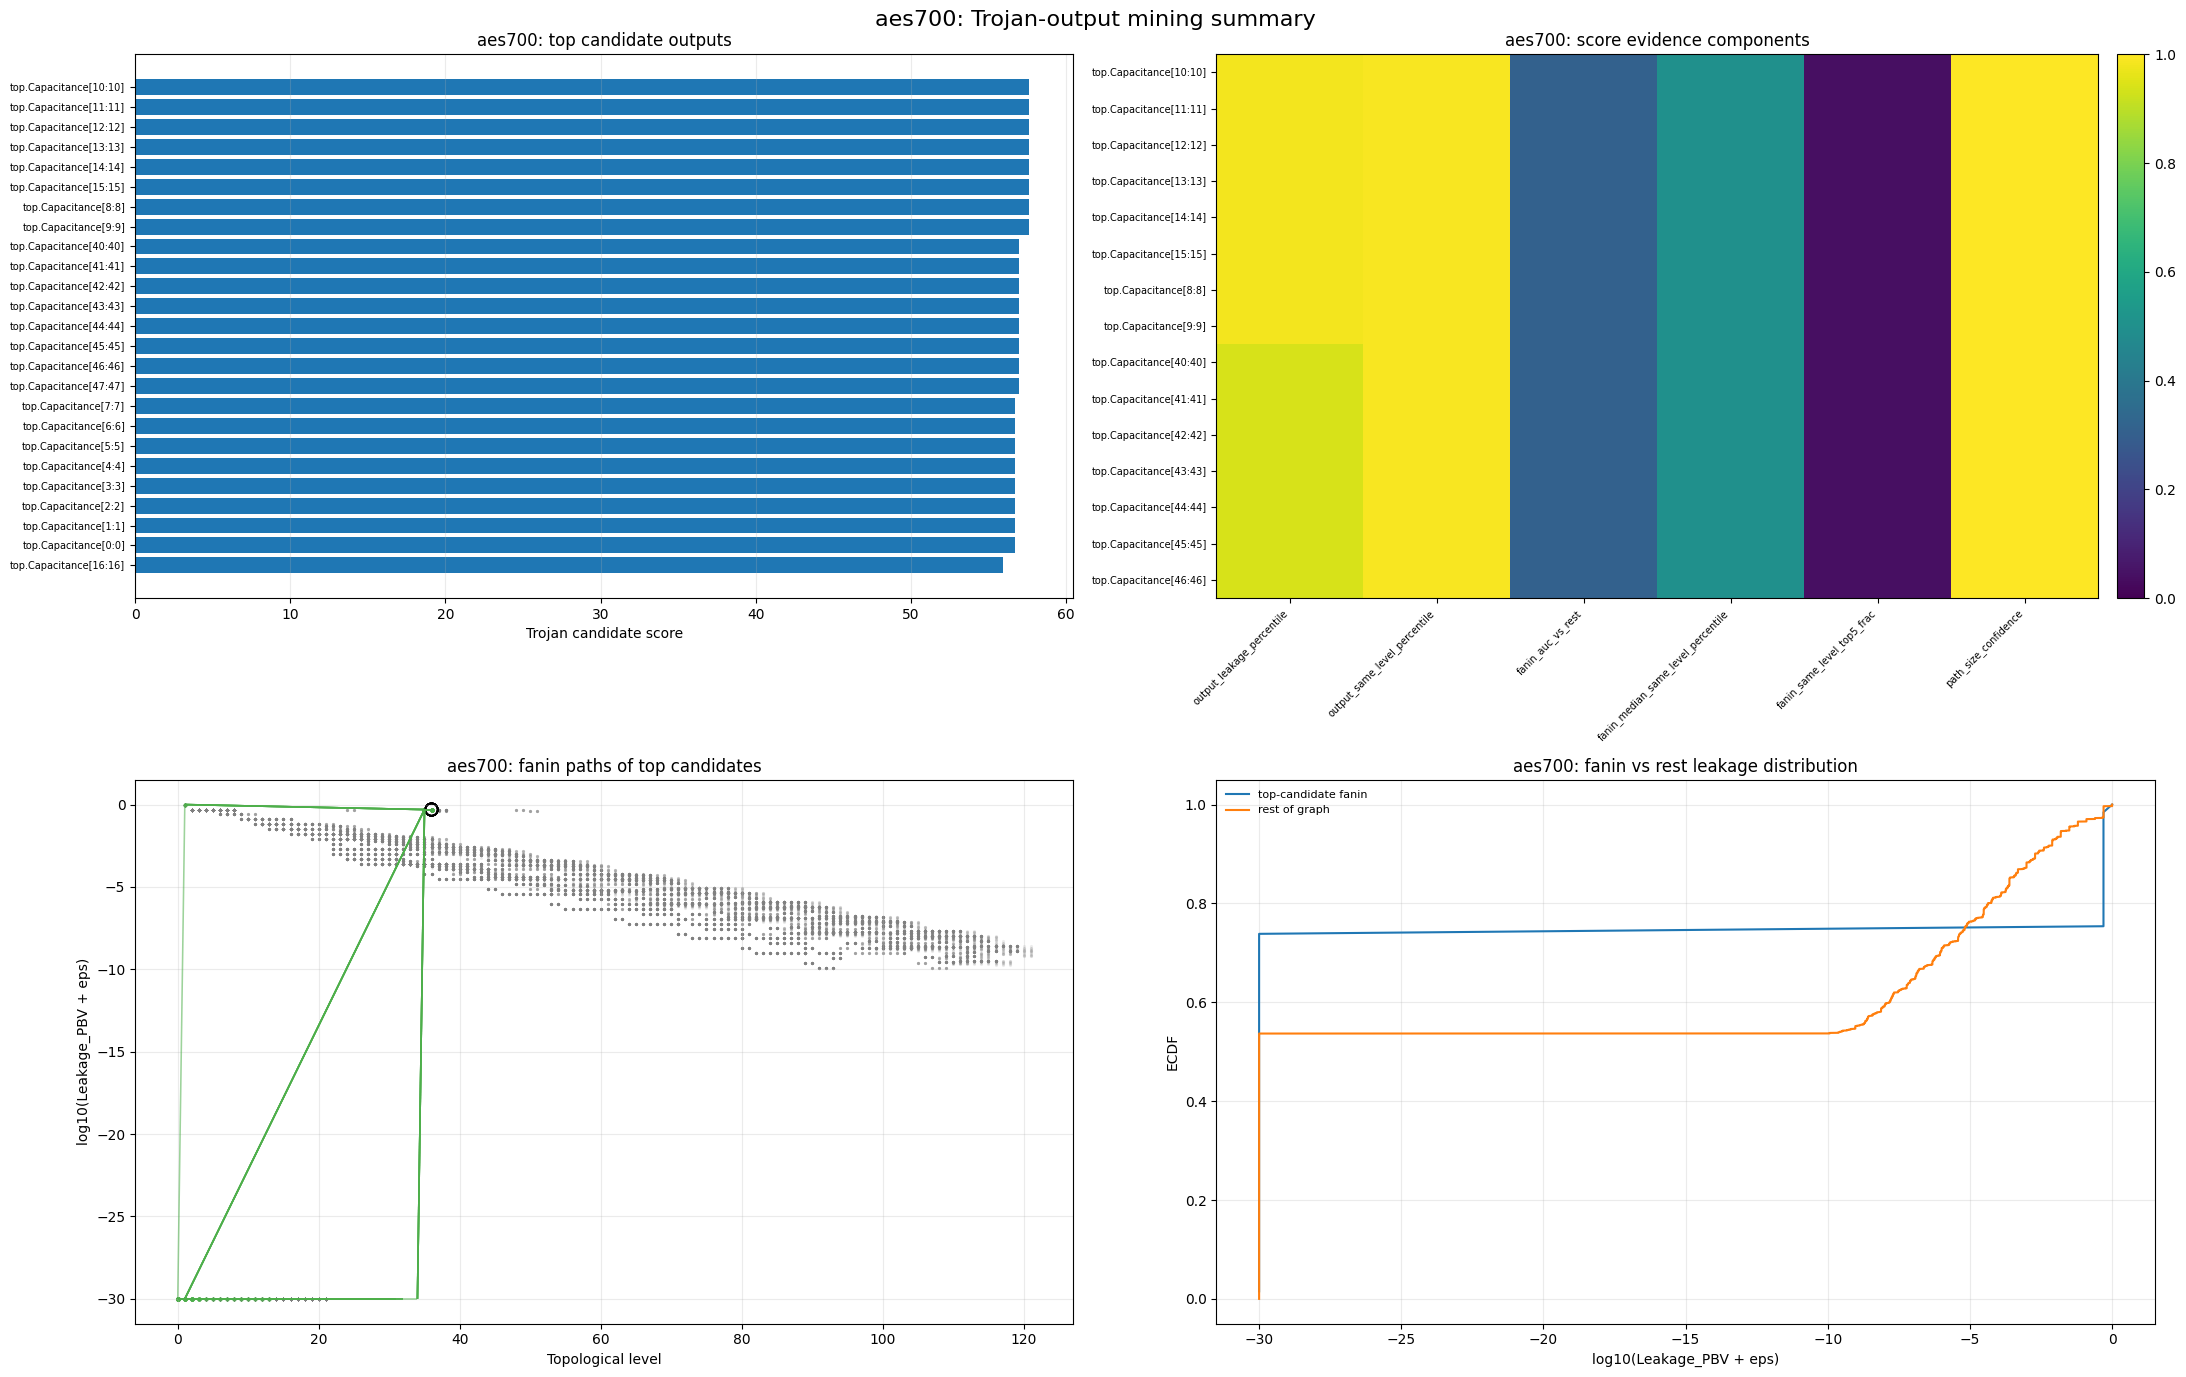

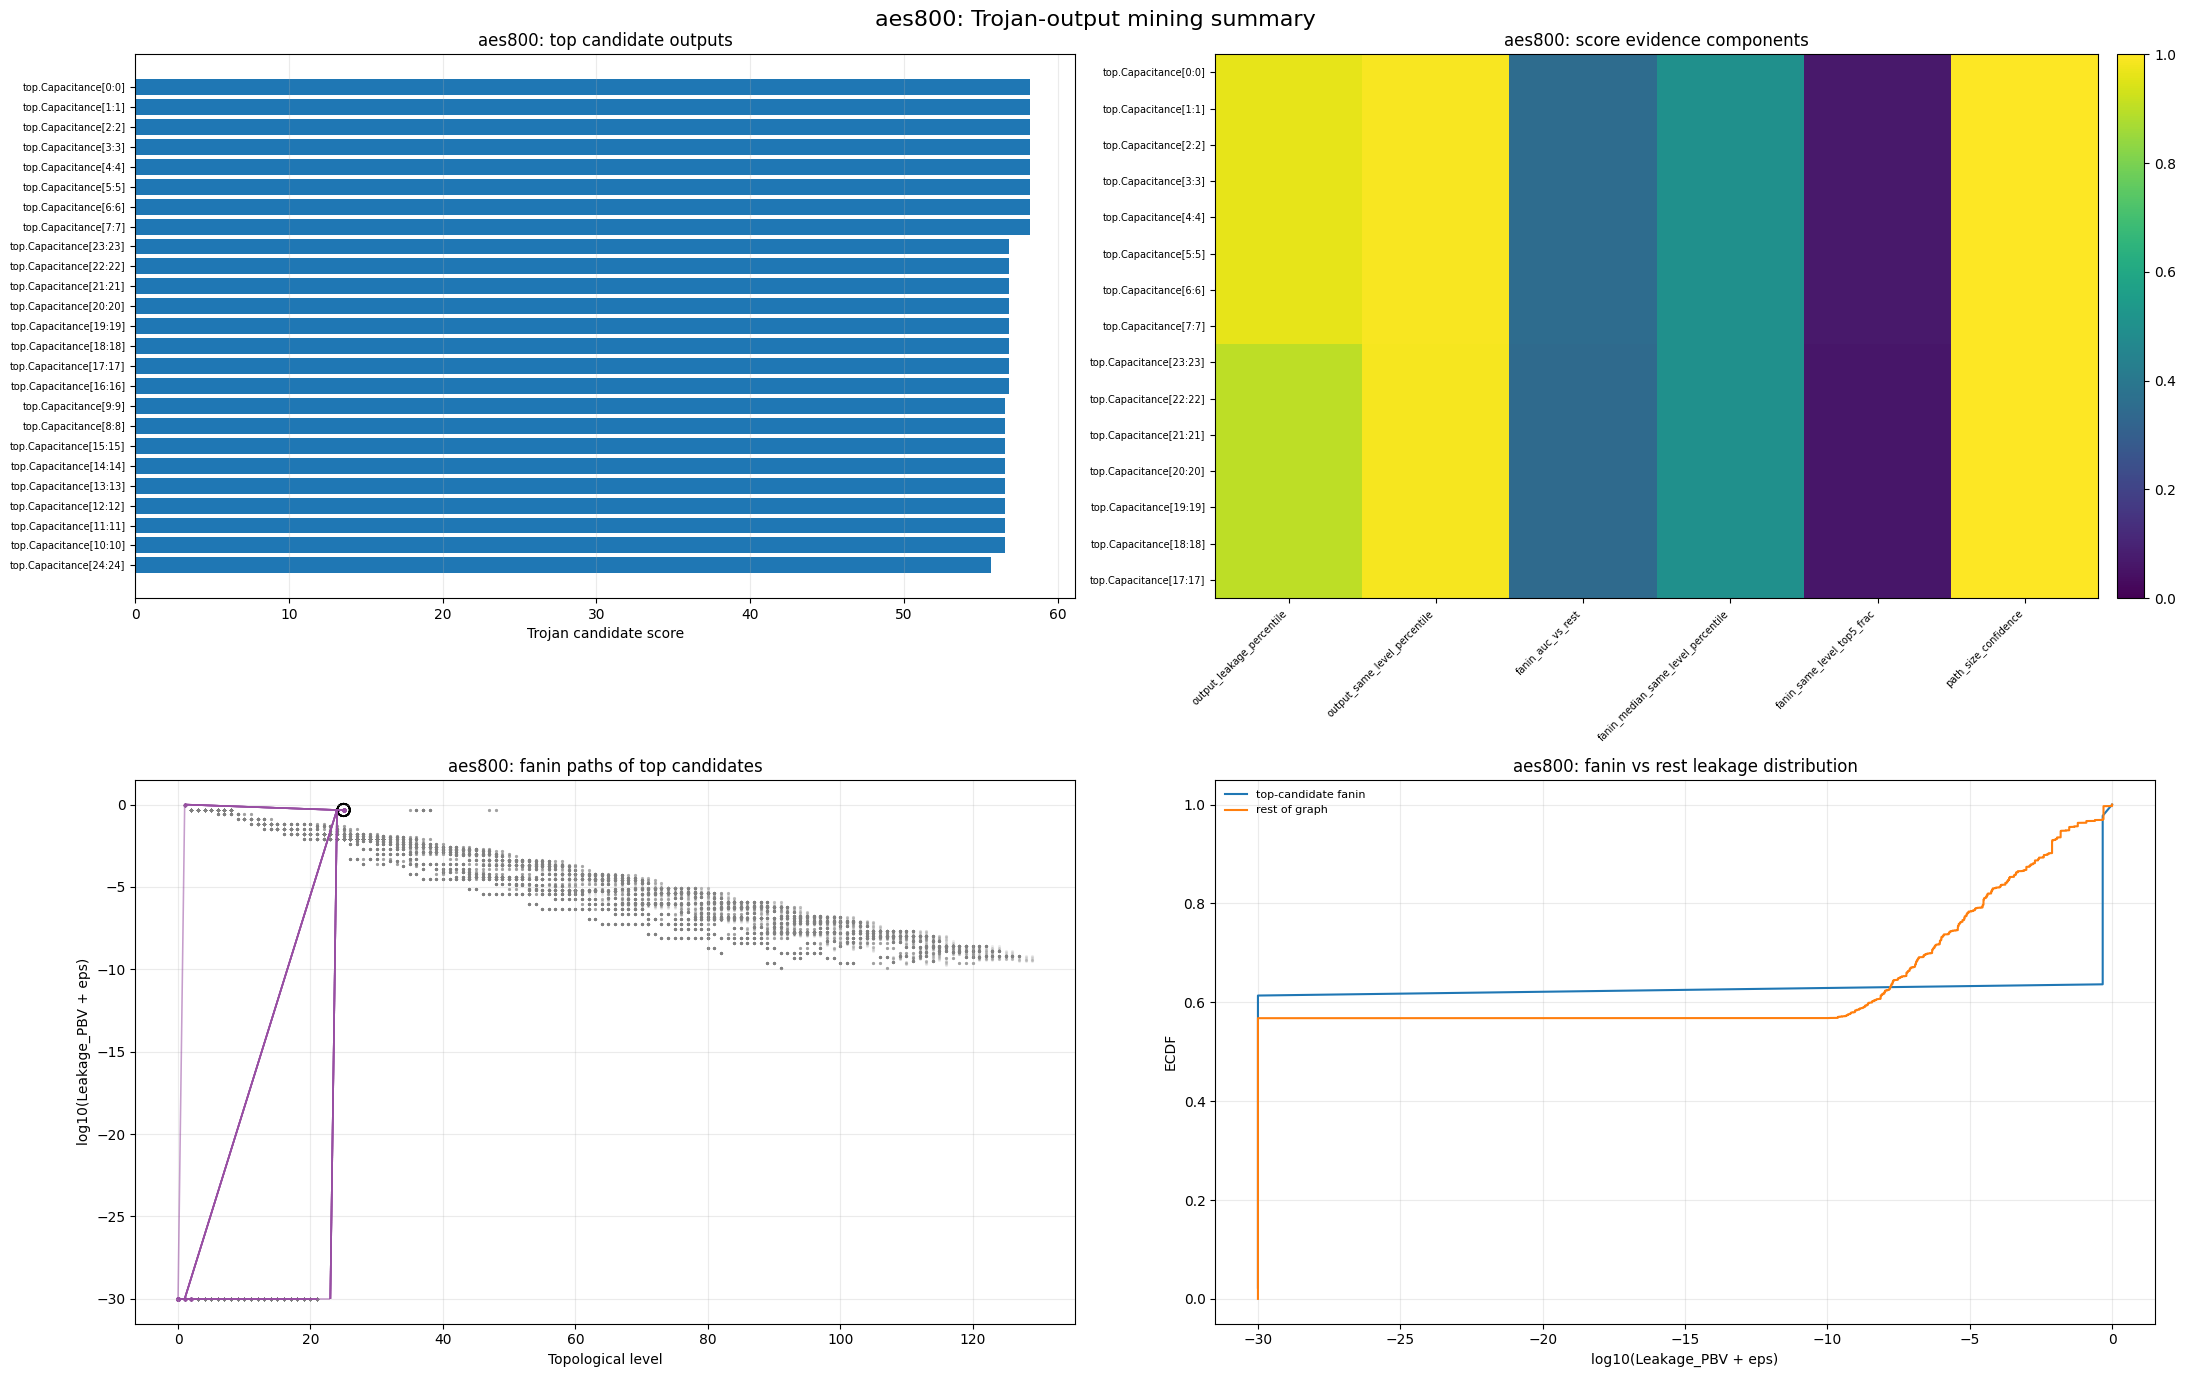

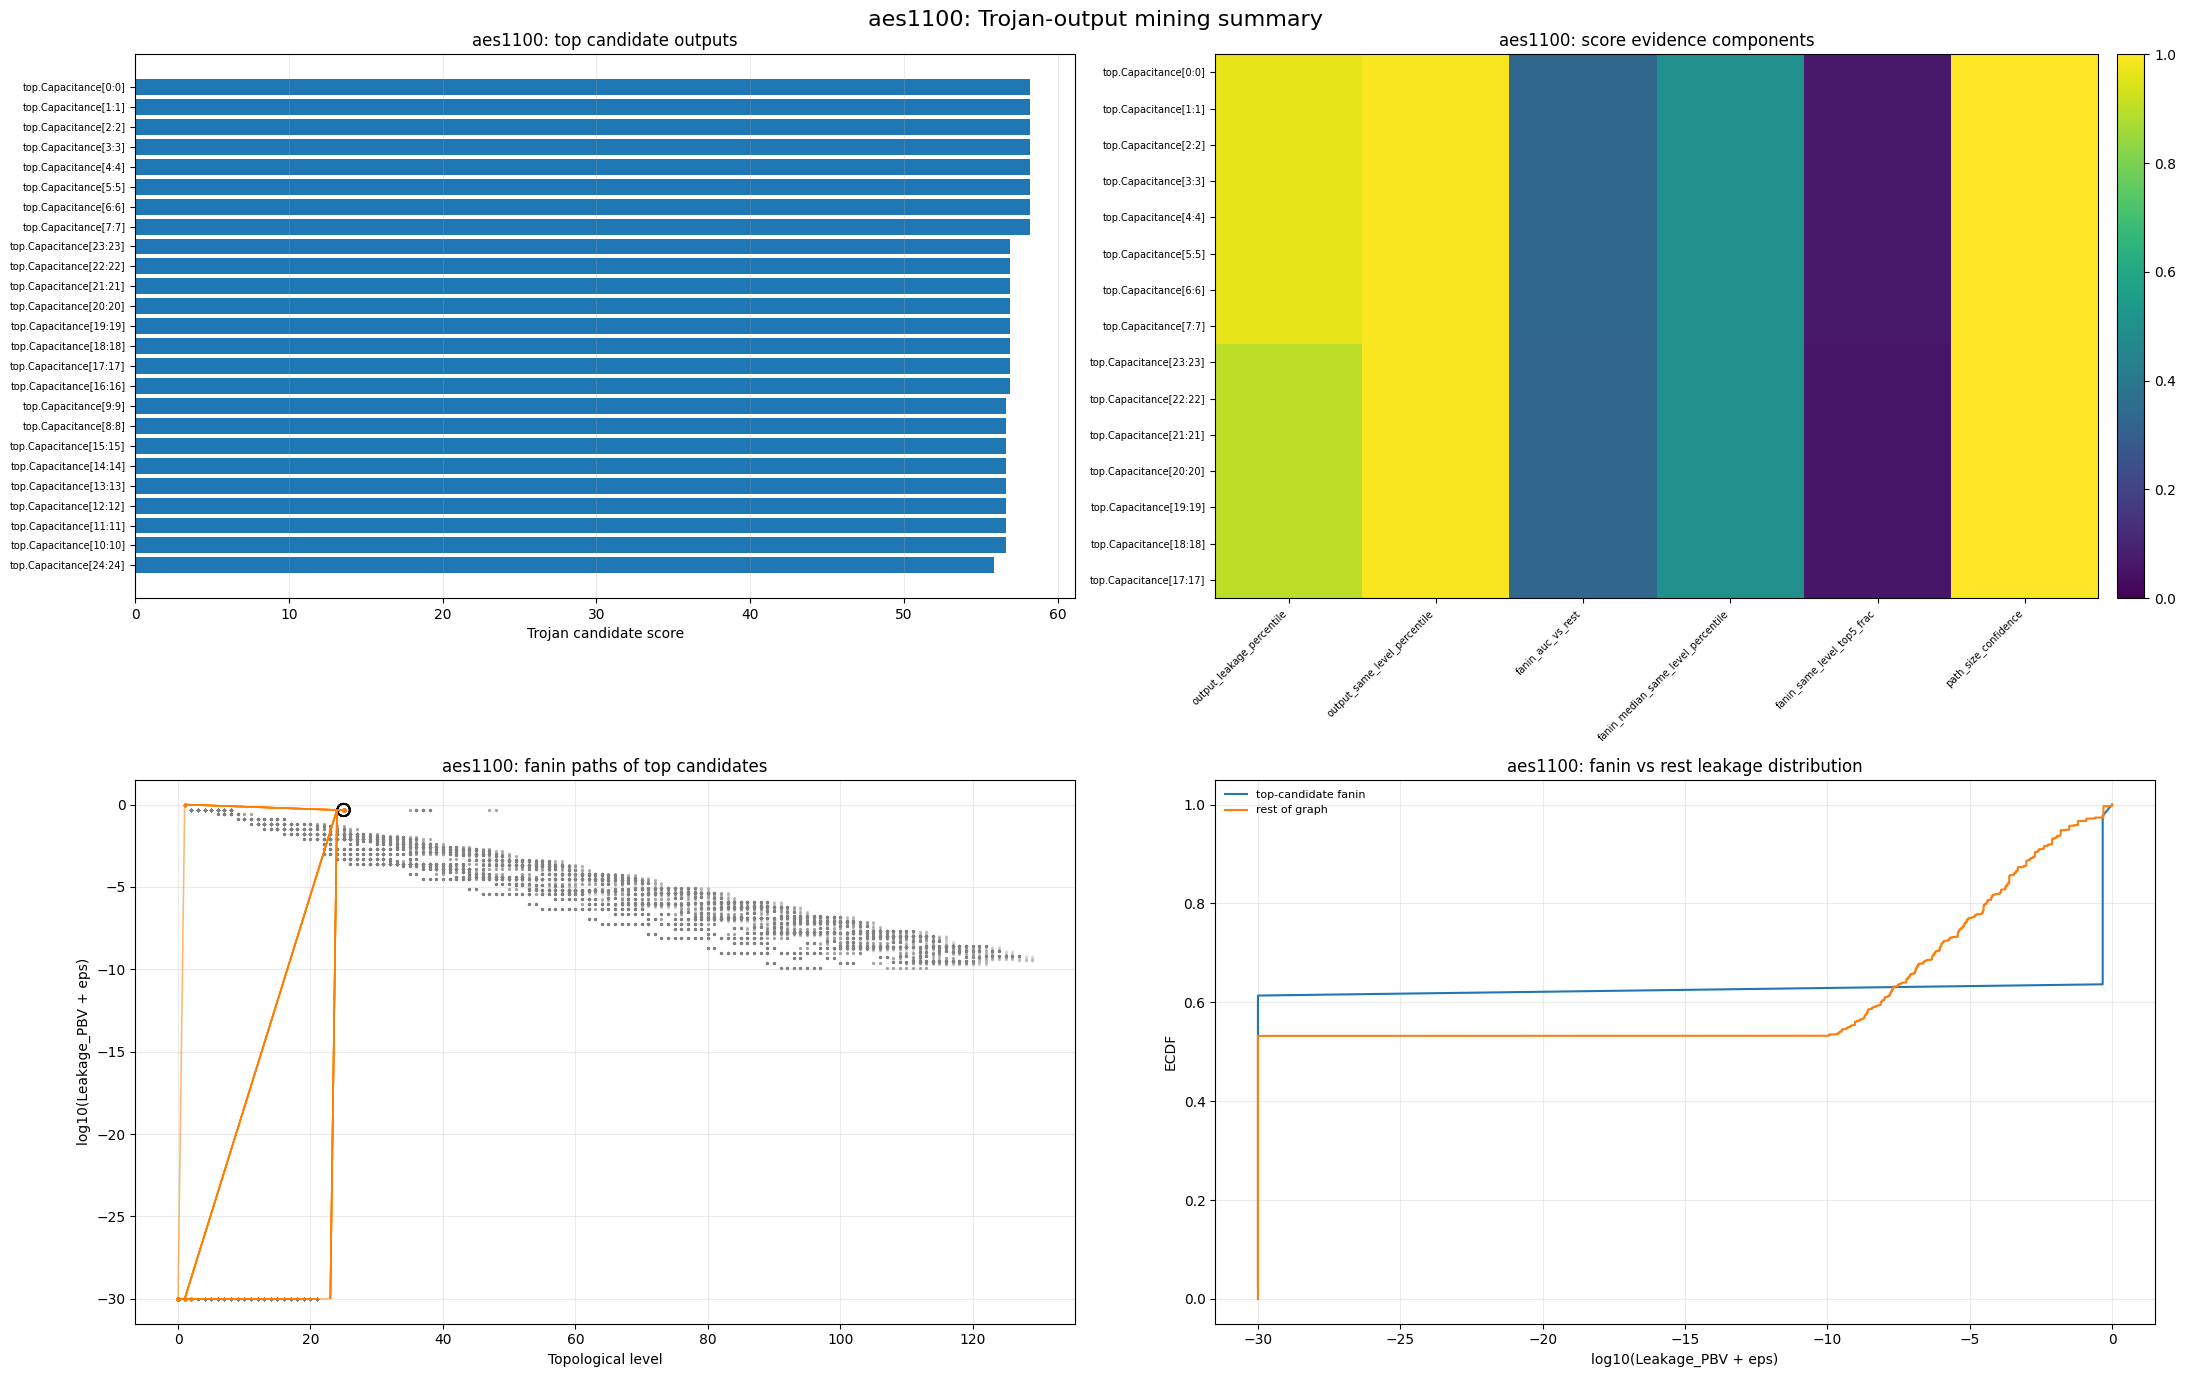

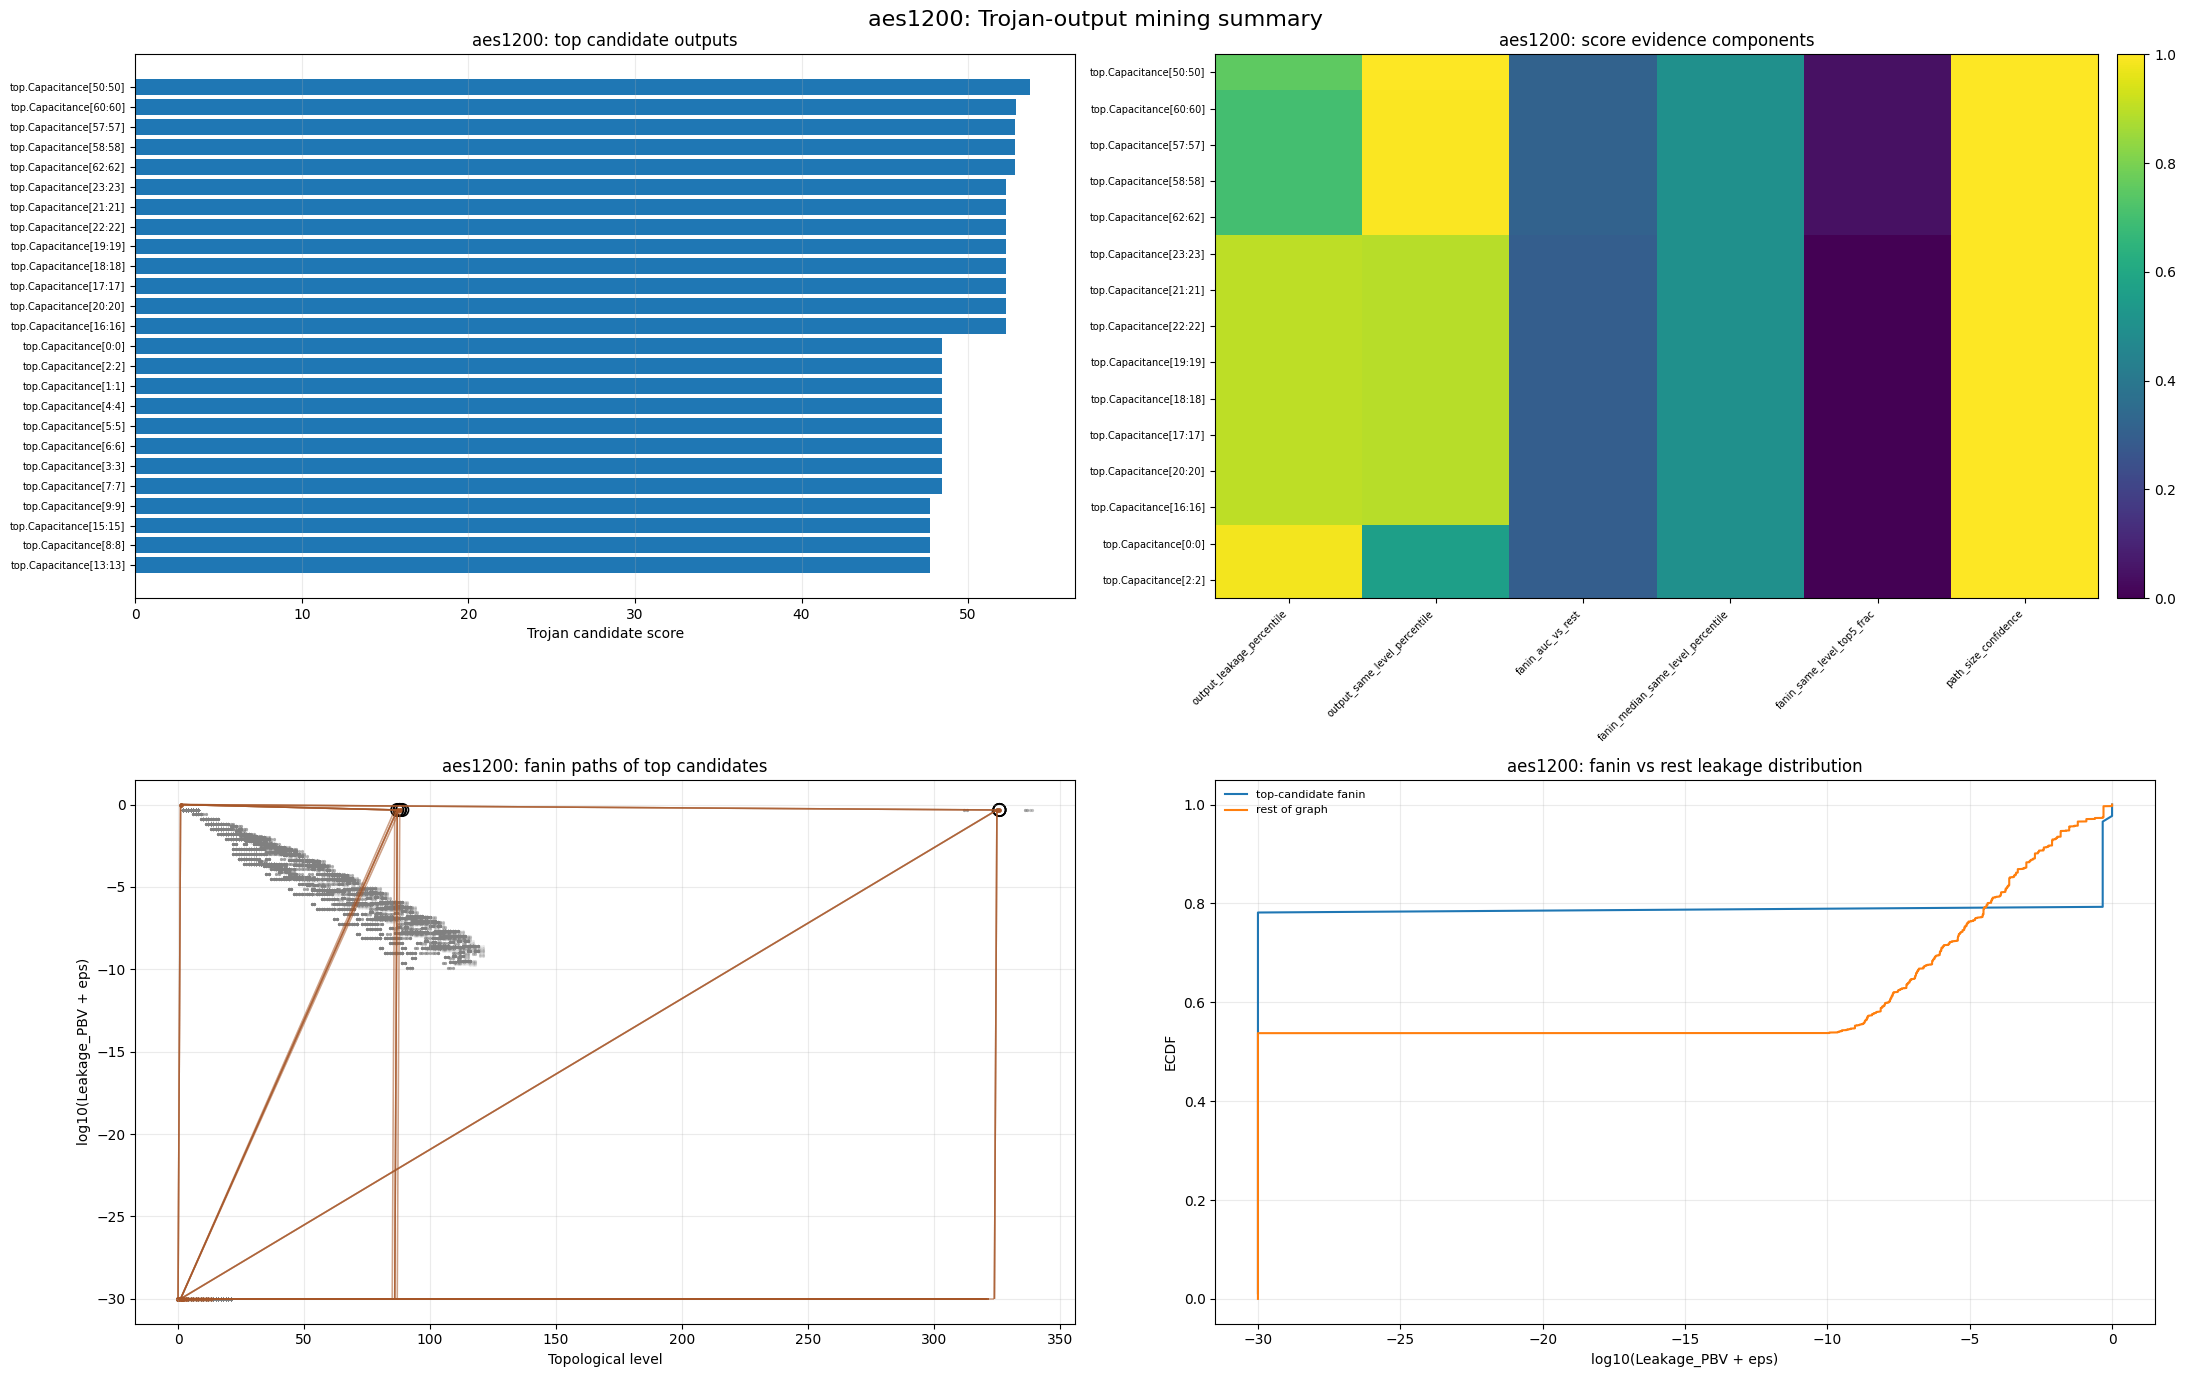

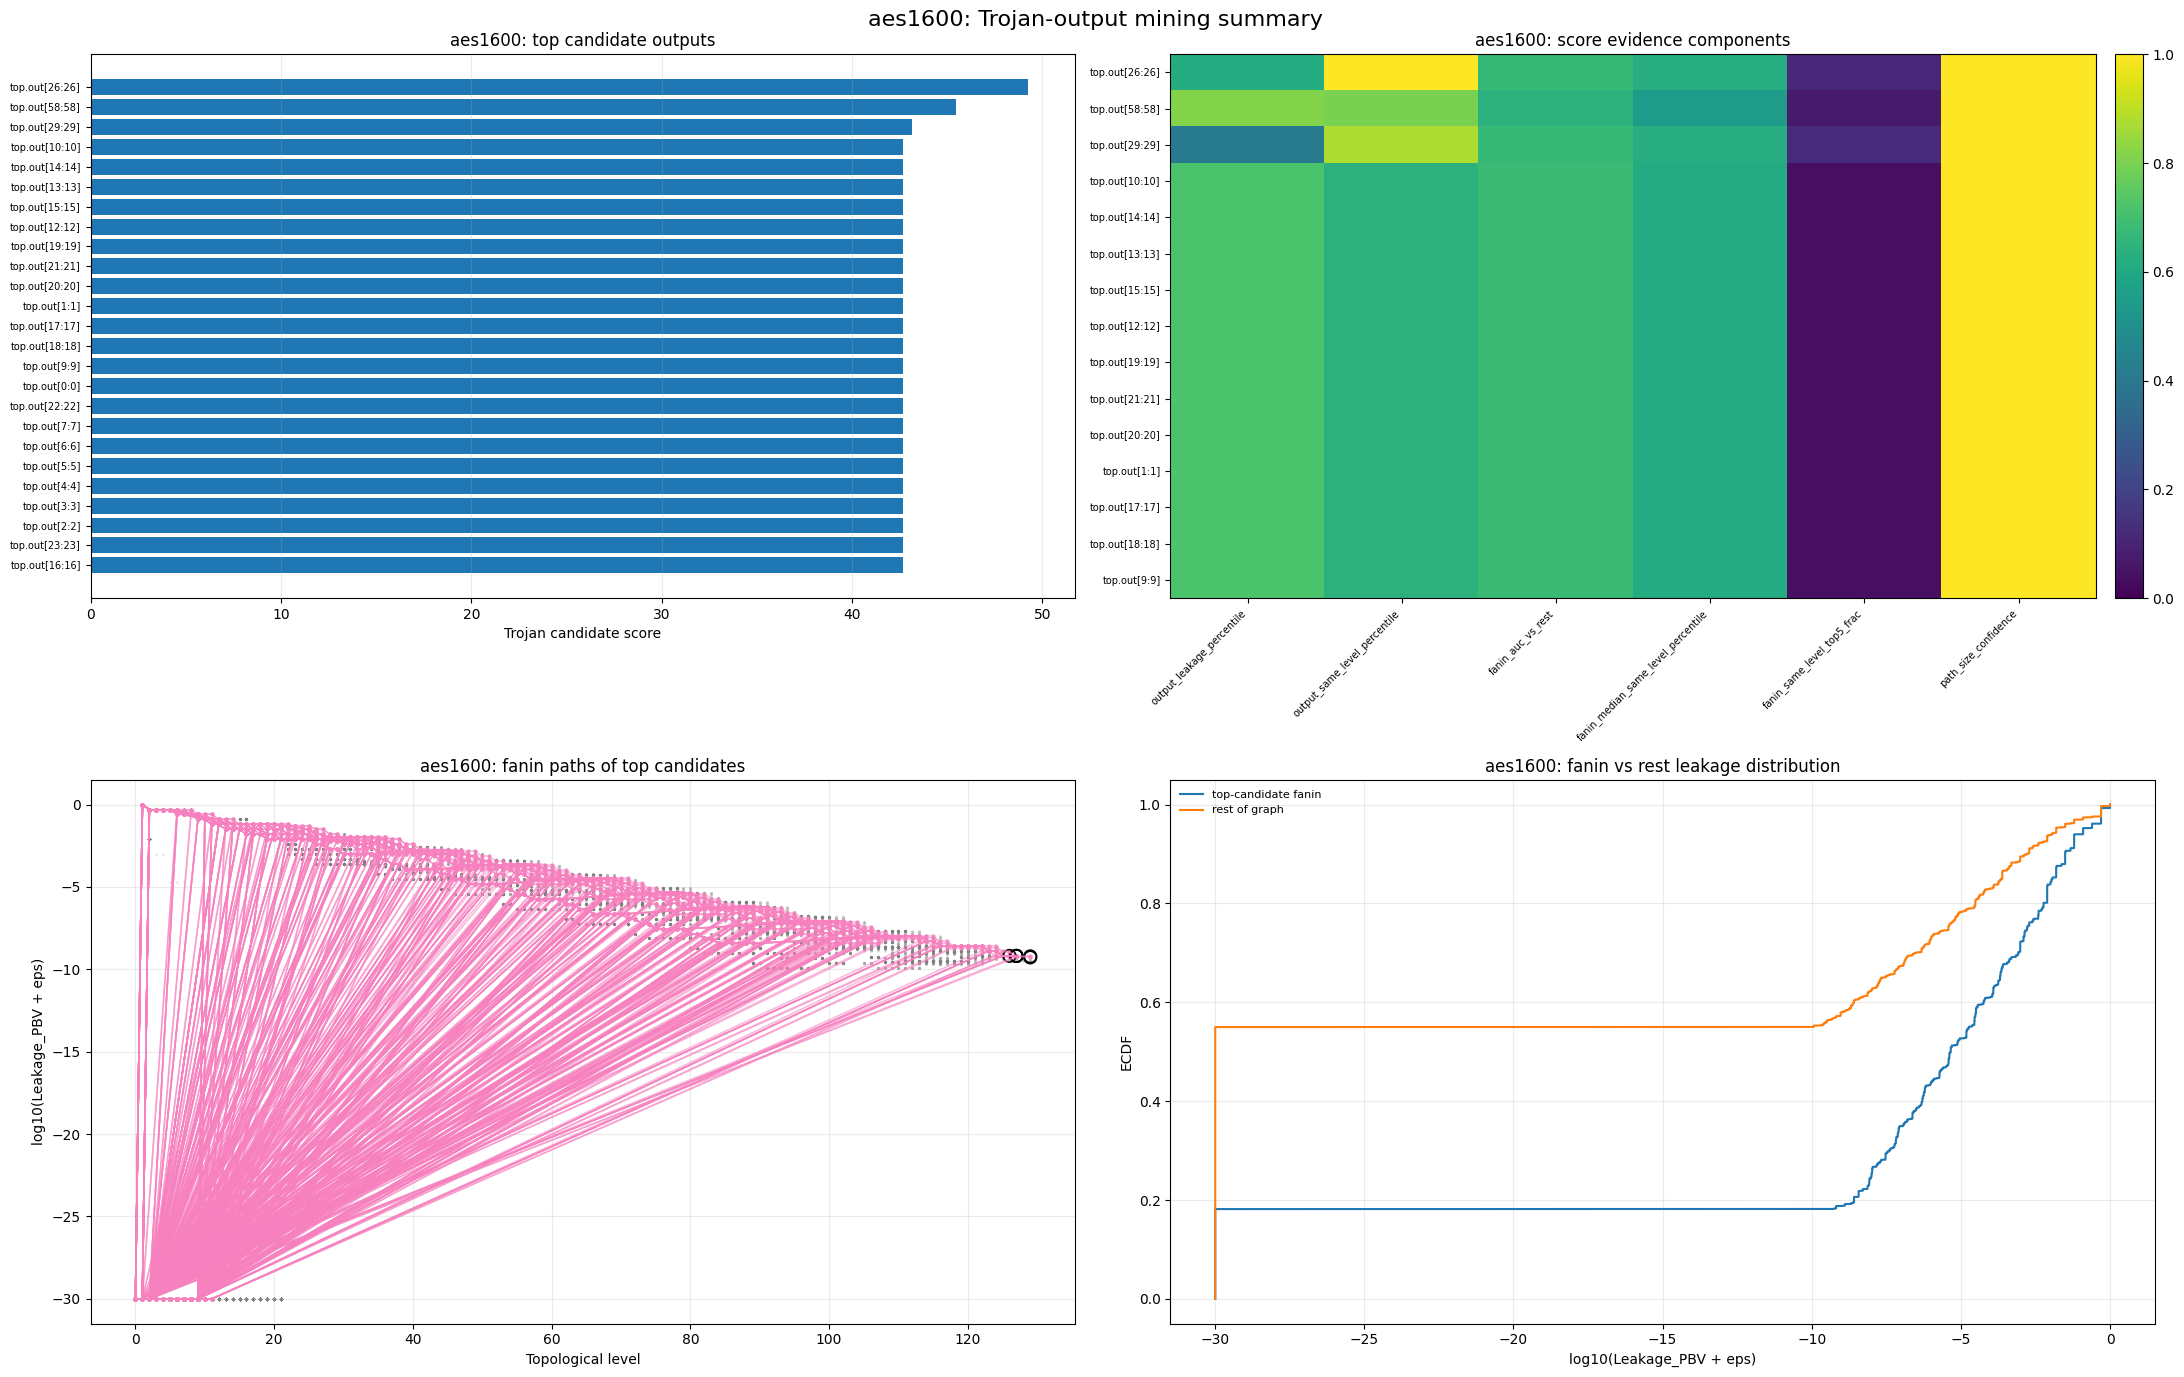

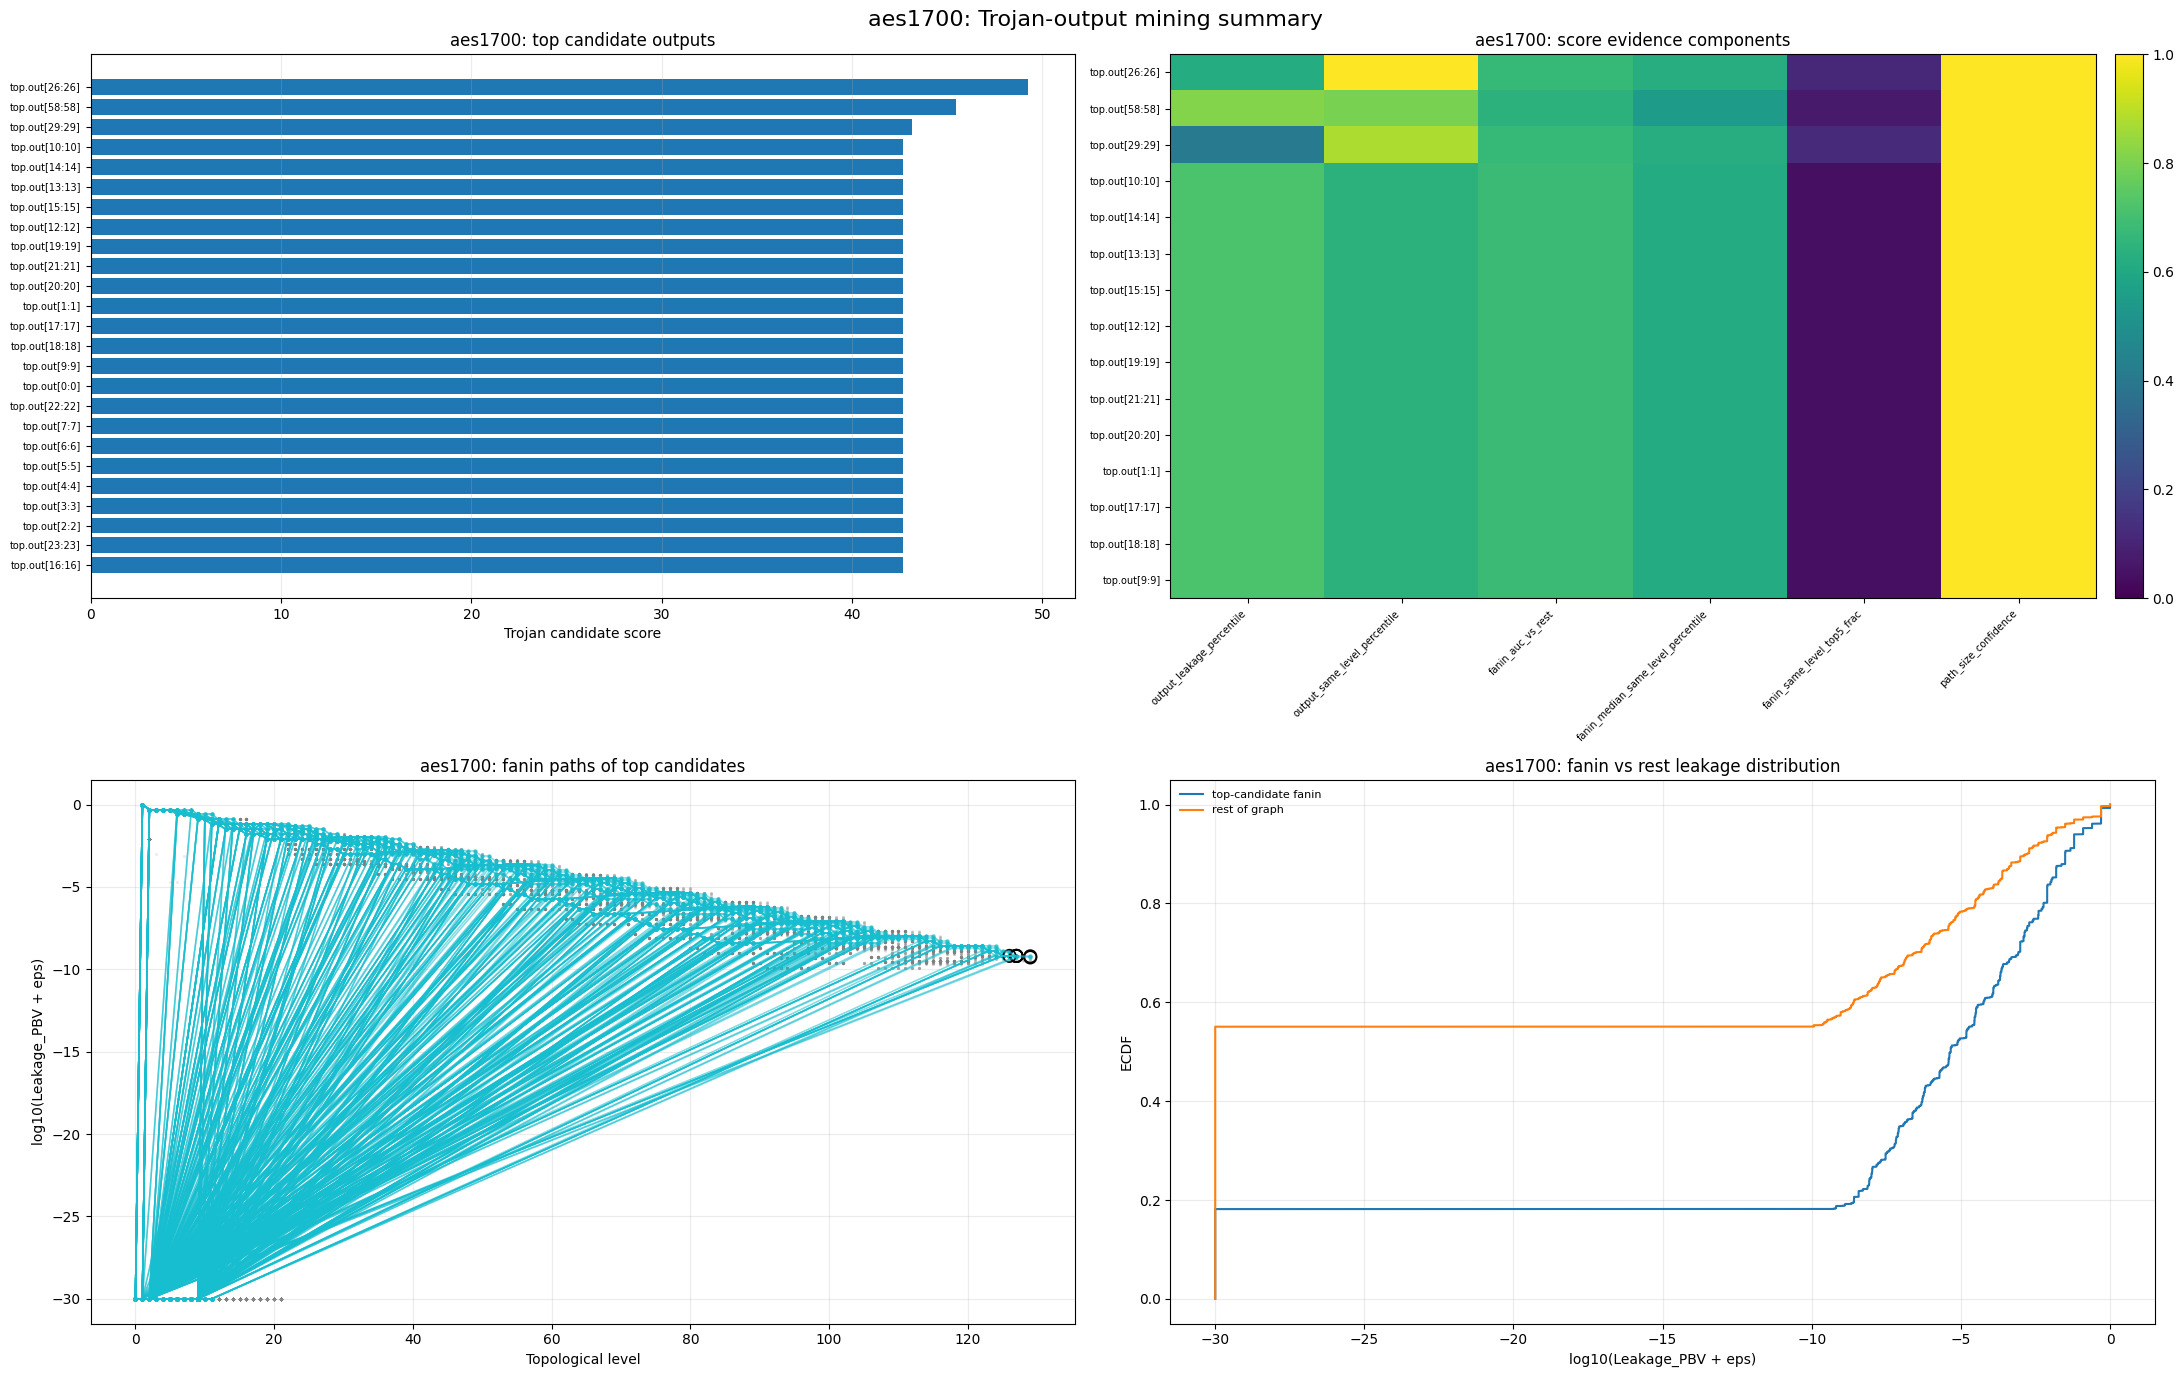

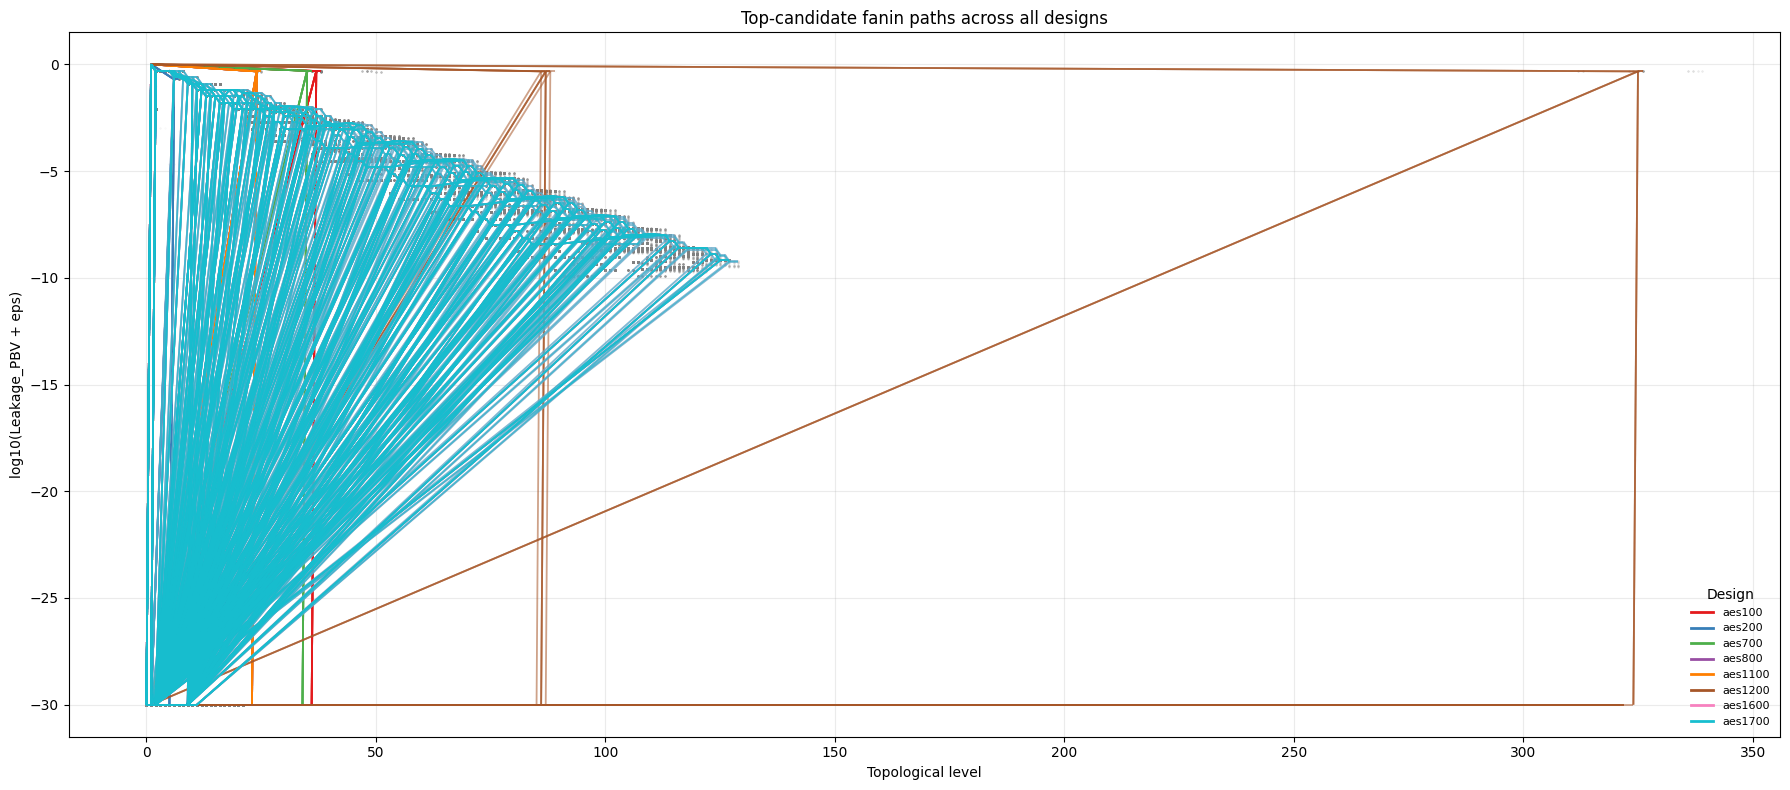

Saved plots:
  fortify/analysis_outputs/leakage_topology/aes100/aes100_candidate_score_bar.png
  fortify/analysis_outputs/leakage_topology/aes100/aes100_candidate_component_heatmap.png
  fortify/analysis_outputs/leakage_topology/aes100/aes100_fanin_overlay_by_level.png
  fortify/analysis_outputs/leakage_topology/aes100/aes100_ecdf_fanin_vs_rest.png
  fortify/analysis_outputs/leakage_topology/aes100/aes100_summary_grid.png
  fortify/analysis_outputs/leakage_topology/aes200/aes200_candidate_score_bar.png
  fortify/analysis_outputs/leakage_topology/aes200/aes200_candidate_component_heatmap.png
  fortify/analysis_outputs/leakage_topology/aes200/aes200_fanin_overlay_by_level.png
  fortify/analysis_outputs/leakage_topology/aes200/aes200_ecdf_fanin_vs_rest.png
  fortify/analysis_outputs/leakage_topology/aes200/aes200_summary_grid.png
  fortify/analysis_outputs/leakage_topology/aes700/aes700_candidate_score_bar.png
  fortify/analysis_outputs/leakage_topology/aes700/aes700_candidate_component_h

In [6]:

# -----------------------------
# Plot only at the end
# -----------------------------
saved_plot_paths = []

for design_index, bundle in enumerate(all_bundles):
    saved_plot_paths.extend(save_individual_graphs(bundle, design_index=design_index))

    if DISPLAY_PER_DESIGN_SUMMARIES:
        saved_plot_paths.append(display_design_summary(bundle, design_index=design_index))

combined_overlay_path = display_combined_overlay(all_bundles)
saved_plot_paths.append(combined_overlay_path)

print("Saved plots:")
for path in saved_plot_paths:
    print(f"  {path}")
